In [1]:
from src.gmm import GMM
from src.dg import DataGenerator
from src.metrics import energy_distance, hellinger_gaussian_diag_gmm, hellinger_normal_gmm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t, gaussian_kde

import torch

from src.test import TorchGaussianMixture
from sklearn.mixture import GaussianMixture

# controled missingness functions adapted from R but not exactly the same
# still using ampute from mice in R
from src.mdm import ampute_mar

Error importing in API mode: ImportError("dlopen(/Users/huimin/Documents/UNIGE PhD/research/nonparametric/.venv/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <1984CB9B-890E-3855-A246-270AC6AC4C62> /Users/huimin/Documents/UNIGE PhD/research/nonparametric/.venv/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
# global parameters
N = 2000
d = 3

n_samples = 2000
k=10

# number of inits for the EM - sklearn and our method
n_inits=20

# Functions to set the MDM distributions

- input1: the probability of the completely observed
- input2: the probability of the worst missingness, i.e., all missing except the last column

In [3]:
def mdm_dist(d, p_complete, p_all_missing=None):
    n_pats = 2**(d-1) - 1
    if p_all_missing is None:
        pm = np.ones(n_pats)
        pm /= pm.sum()
        pm *= 1 - p_complete
        return np.append(pm, p_complete)

    pm = np.ones(n_pats - 1)
    pm /= pm.sum()
    pm *= 1 - p_complete - p_all_missing
    pm = np.insert(pm, 0, p_all_missing)
    return np.append(pm, p_complete)

# Decrease the probability of fully observed

In [4]:
pc_range = [0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.1]

## Case 1: Gaussian mixture with $k=5$

In [5]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Sklearn GM

In [6]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [7]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM with increasing missingness

In [8]:
eds = []
for p in pc_range:
    pp = mdm_dist(d, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
    gmmt.fit(X_filled, M_full)

    gmmt_ed = [energy_distance(X_filled, gmmt.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

### New GM with full data

In [9]:

gmmt_full = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
gmmt_full.fit(X, M_full)

gmmt_full_ed = [energy_distance(X, gmmt_full.sample(n_samples)[0]) for _ in range(100)]

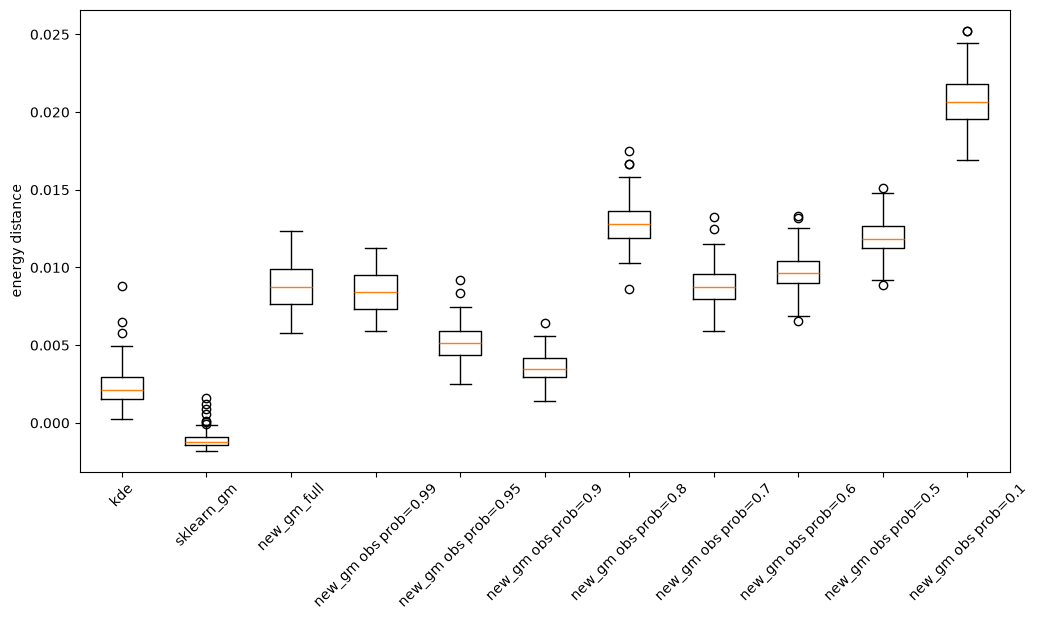

In [10]:
labels = ['new_gm obs prob=' + str(x) for x in pc_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmmt_full_ed, *eds])
plt.xticks(list(range(1,len(pc_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

## Case 2: Normal

$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$

In [11]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Sklearn GM

In [12]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [13]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM with increasing missingness

In [14]:
eds = []
for p in pc_range:
    pp = mdm_dist(d, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
    gmmt.fit(X_filled, M_full)

    gmmt_ed = [energy_distance(X_filled, gmmt.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

### New GM with full data

In [ ]:
gmmt_full = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
gmmt_full.fit(X, M_full)

gmmt_full_ed = [energy_distance(X, gmmt_full.sample(n_samples)[0]) for _ in range(100)]

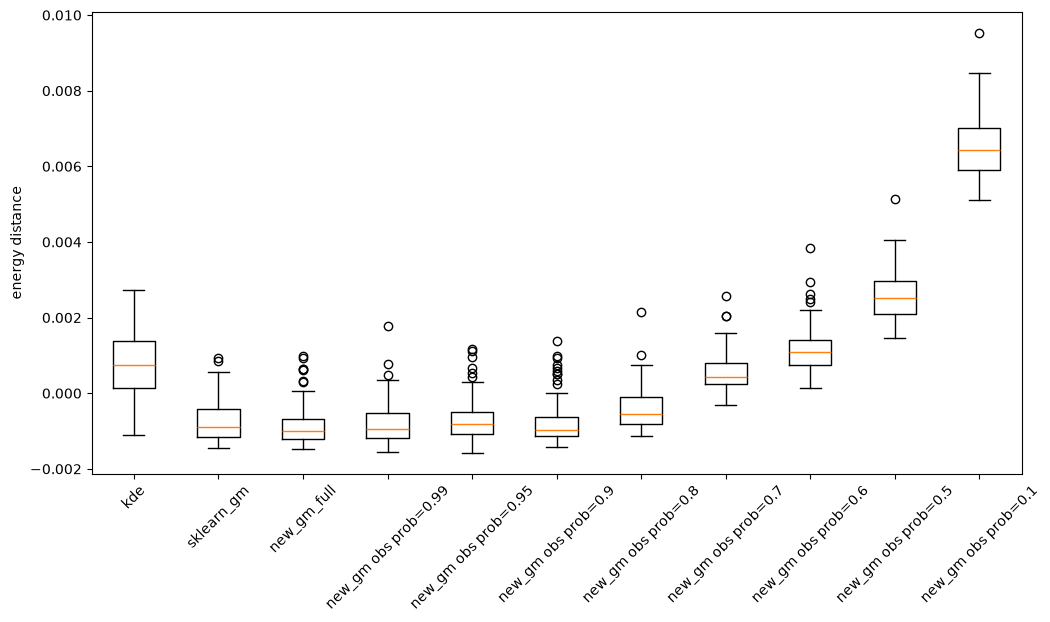

In [16]:
labels = ['new_gm obs prob=' + str(x) for x in pc_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmmt_full_ed, *eds])
plt.xticks(list(range(1,len(pc_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

# Increase the probability of the worst missingness probability

In [17]:
pc = 0.5
pam_range = [0.05, 0.1, 0.2, 0.3, 0.4]
len(pam_range)

5

## Case 1: Gaussian mixture with $k=5$

In [18]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Sklearn GM

In [19]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [20]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM with increasing missingness

In [21]:
eds = []
for p in pam_range:
    pp = mdm_dist(d, pc, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
    gmmt.fit(X_filled, M_full)

    gmmt_ed = [energy_distance(X_filled, gmmt.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

### New GM with full data

In [22]:

gmmt_full = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
gmmt_full.fit(X, M_full)

gmmt_full_ed = [energy_distance(X, gmmt_full.sample(n_samples)[0]) for _ in range(100)]

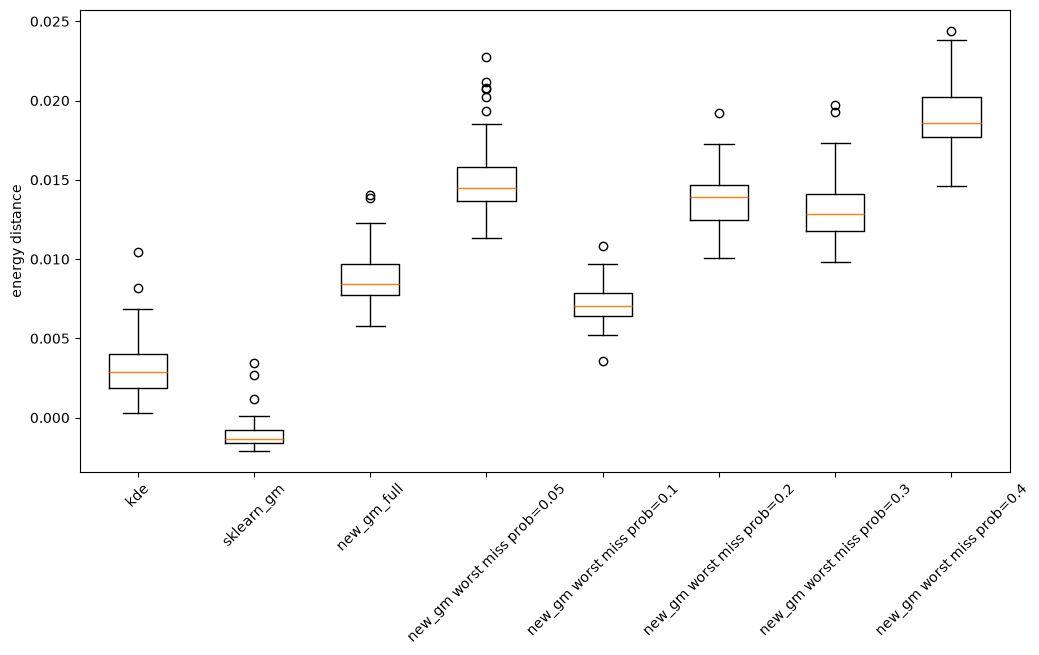

In [23]:
labels = ['new_gm worst miss prob=' + str(x) for x in pam_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmmt_full_ed, *eds])
plt.xticks(list(range(1,len(pam_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()

## Case 2: Normal

$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$

In [24]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)
M_full = torch.ones_like(M)

### Sklearn GM

In [25]:
gmm_sk = GaussianMixture(
    n_components=k,
    covariance_type='diag',
    #random_state=0,
    init_params='random',
    n_init=n_inits
)
gmm_sk.fit(X)

gmm_sk_ed = [energy_distance(X, torch.tensor(gmm_sk.sample(n_samples)[0])) for _ in range(100)]

### KDE

In [26]:
kde = gaussian_kde(X.T)
kde_ed = [energy_distance(X, torch.tensor(kde.resample(n_samples)).T).item() for _ in range(100)]

### New GM with increasing missingness

In [27]:
eds = []
for p in pam_range:
    pp = mdm_dist(d, pc, p)
    X0, M = ampute_mar(X, pp)
    X_filled = torch.nan_to_num(X0, nan=0.0)
    gmmt = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
    gmmt.fit(X_filled, M_full)

    gmmt_ed = [energy_distance(X_filled, gmmt.sample(n_samples)[0]) for _ in range(100)]
    eds.append(gmmt_ed)

### New GM with full data

In [28]:

gmmt_full = TorchGaussianMixture(n_components=k, device='cpu', cov_type='uni_diag', n_init=n_inits)
gmmt_full.fit(X, M_full)

gmmt_full_ed = [energy_distance(X, gmmt_full.sample(n_samples)[0]) for _ in range(100)]

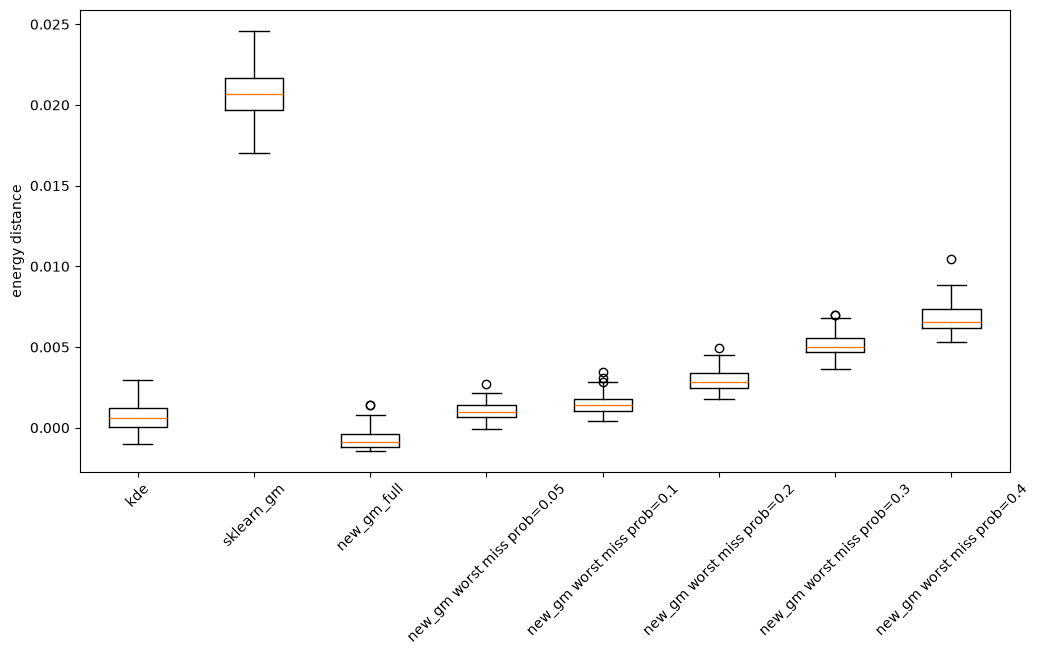

In [29]:
labels = ['new_gm worst miss prob=' + str(x) for x in pam_range]

plt.figure(figsize=(12, 6))
plt.boxplot([kde_ed, gmm_sk_ed, gmmt_full_ed, *eds])
plt.xticks(list(range(1,len(pam_range) + 4)), ['kde', 'sklearn_gm', 'new_gm_full', *labels], rotation=45)
plt.ylabel('energy distance')
plt.show()